# Simple LangGraph Example with Visualization

This notebook demonstrates a basic LangGraph setup with state management and visualization.


In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles


## Define the State

First, we define the state structure that will flow through our graph.


In [ ]:
class State(TypedDict):
    goal: str
    count: int
    output: str


## Define Node Functions

Create simple node functions that process the state.


In [3]:
def process_input(state: State) -> dict:
    """Process the input and increment count."""
    print(f"Processing: {state['input']}")
    return {"count": state.get('count', 0) + 1}

def transform_data(state: State) -> dict:
    """Transform the data."""
    print(f"Transforming at count: {state['count']}")
    return {"count": state['count'] + 1}

def generate_output(state: State) -> dict:
    """Generate final output."""
    result = f"Processed '{state['input']}' through {state['count']} steps"
    print(f"Result: {result}")
    return {"output": result}


## Build the Graph

Now we construct the graph by adding nodes and edges.


In [4]:
# Create the graph builder
builder = StateGraph(State)

# Add nodes
builder.add_node("process", process_input)
builder.add_node("transform", transform_data)
builder.add_node("output", generate_output)

# Add edges to define the flow
builder.add_edge(START, "process")
builder.add_edge("process", "transform")
builder.add_edge("transform", "output")
builder.add_edge("output", END)

# Compile the graph
graph = builder.compile()

print("Graph built successfully!")


Graph built successfully!


## Visualize the Graph

LangGraph provides built-in visualization with `draw_mermaid_png()`.


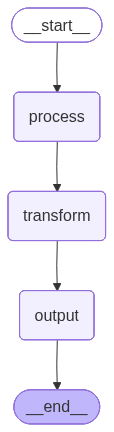

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))


### Optional: Customize Visualization Style

You can customize the graph visualization with styling options.


In [ ]:
# Example with custom styling
display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API,
    curve_style=CurveStyle.LINEAR
)))


## Run the Graph

Execute the graph with sample input.


In [ ]:
# Run the graph
initial_state = {"input": "Hello, LangGraph!", "count": 0}
result = graph.invoke(initial_state)

print("\nFinal State:")
print(result)


## Stream the Graph Execution

You can also stream the graph execution to see intermediate states.


In [ ]:
print("\nStreaming execution:")
for step in graph.stream(initial_state, stream_mode="values"):
    print(f"Step state: {step}")
